##### ARTI 560 - Computer Vision

## Instance Segmentation - Exercise 

### Objective

In this exercise, you will implement **Instance Object Segmentation** using a pretrained **Mask R-CNN model** from TensorFlow Hub.

You will follow these steps:

1. **Load the pretrained Mask R-CNN model**  
   - Use this Kaggle link: [Mask R-CNN Inception-ResNet-v2](https://www.kaggle.com/models/tensorflow/mask-rcnn-inception-resnet-v2)  

2. **Select and load 5 different images**  
   - Choose **5 diverse images**, including:  
      - Crowded scenes with multiple objects  
      - Unusual angles, lighting conditions, or occlusions  
      - At least **one image containing multiple objects of the same class** 

3. **Perform inference using the model**  
   - Feed images to the model to obtain predictions  

4. **Extract prediction outputs**  
   - **Bounding boxes** – coordinates of detected objects  
   - **Class labels** – names of detected objects  
   - **Segmentation masks** – pixel-wise masks for each object  

5. **Visualize the results**  
   - Overlay masks on detected objects  
   - Draw bounding boxes around objects  
   - Display class names and confidence scores  

6. **Experiment with confidence thresholds**  
   - Default threshold: **0.5**  
   - Lower threshold: **0.3** to detect more objects (may include false positives)  

---

- Keep in mind:  
  - Some objects may not be recognized at the default threshold 
  - The model only detects objects from the **COCO dataset (80 classes)**  


In [1]:
!pip -q install tensorflow tensorflow-hub pillow matplotlib opencv-python

In [2]:
import os
import cv2
import json
import numpy as np
import tensorflow as tf
import tensorflow_hub as hub
import matplotlib.pyplot as plt
from PIL import Image
from urllib.request import urlopen

In [11]:
import os
print(os.getcwd())
print(os.listdir())

/content
['.config', 'sample_data']


In [12]:
import tensorflow_hub as hub

MODEL_HANDLE = "https://tfhub.dev/tensorflow/mask_rcnn/inception_resnet_v2_1024x1024/1"
detector = hub.load(MODEL_HANDLE)

print("Model loaded successfully")

Model loaded successfully


In [13]:
COCO_LABELS = {
    1: 'person', 2: 'bicycle', 3: 'car', 4: 'motorcycle', 5: 'airplane',
    6: 'bus', 7: 'train', 8: 'truck', 9: 'boat', 10: 'traffic light',
    11: 'fire hydrant', 13: 'stop sign', 14: 'parking meter', 15: 'bench',
    16: 'bird', 17: 'cat', 18: 'dog', 19: 'horse', 20: 'sheep',
    21: 'cow', 22: 'elephant', 23: 'bear', 24: 'zebra', 25: 'giraffe',
    27: 'backpack', 28: 'umbrella', 31: 'handbag', 32: 'tie', 33: 'suitcase',
    34: 'frisbee', 35: 'skis', 36: 'snowboard', 37: 'sports ball', 38: 'kite',
    39: 'baseball bat', 40: 'baseball glove', 41: 'skateboard', 42: 'surfboard',
    43: 'tennis racket', 44: 'bottle', 46: 'wine glass', 47: 'cup',
    48: 'fork', 49: 'knife', 50: 'spoon', 51: 'bowl', 52: 'banana',
    53: 'apple', 54: 'sandwich', 55: 'orange', 56: 'broccoli', 57: 'carrot',
    58: 'hot dog', 59: 'pizza', 60: 'donut', 61: 'cake', 62: 'chair',
    63: 'couch', 64: 'potted plant', 65: 'bed', 67: 'dining table',
    70: 'toilet', 72: 'tv', 73: 'laptop', 74: 'mouse', 75: 'remote',
    76: 'keyboard', 77: 'cell phone', 78: 'microwave', 79: 'oven',
    80: 'toaster', 81: 'sink', 82: 'refrigerator', 84: 'book', 85: 'clock',
    86: 'vase', 87: 'scissors', 88: 'teddy bear', 89: 'hair drier', 90: 'toothbrush'
}

In [34]:
IMAGE_URLS = [
    "https://images.unsplash.com/photo-1502877338535-766e1452684a",  # cars
    "https://images.unsplash.com/photo-1544005313-94ddf0286df2",  # people
    "https://images.unsplash.com/photo-1517849845537-4d257902454a",  # dog
    "https://images.unsplash.com/photo-1492724441997-5dc865305da7",  # crowded
    "https://images.unsplash.com/photo-1519710164239-da123dc03ef4"   # cat
]

In [35]:
from urllib.request import Request, urlopen
from PIL import Image
import numpy as np

def load_image_from_url(url):
    req = Request(url, headers={"User-Agent": "Mozilla/5.0"})
    image = np.array(Image.open(urlopen(req)).convert("RGB"))
    return image

In [36]:
images = [load_image_from_url(url) for url in IMAGE_URLS]

In [38]:
def preprocess_image(image):
    image_tensor = tf.convert_to_tensor(image, dtype=tf.uint8)
    image_tensor = tf.expand_dims(image_tensor, axis=0)  # [1, H, W, 3]
    return image_tensor

In [39]:
def run_inference(image):
    input_tensor = preprocess_image(image)
    outputs = detector(input_tensor)

    result = {key: value.numpy() for key, value in outputs.items()}
    return result

In [40]:
def extract_predictions(result, threshold=0.5):
    boxes = result["detection_boxes"][0]          # [N, 4]
    classes = result["detection_classes"][0].astype(np.int32)
    scores = result["detection_scores"][0]

    if "detection_masks" in result:
        masks = result["detection_masks"][0]      # [N, mask_h, mask_w]
    else:
        masks = None

    keep = scores >= threshold

    boxes = boxes[keep]
    classes = classes[keep]
    scores = scores[keep]
    masks = masks[keep] if masks is not None else None

    return boxes, classes, scores, masks

In [41]:
def resize_mask_to_box(mask, box, image_shape):
    h, w = image_shape[:2]
    y1, x1, y2, x2 = box

    y1 = int(y1 * h)
    x1 = int(x1 * w)
    y2 = int(y2 * h)
    x2 = int(x2 * w)

    y1 = max(0, y1)
    x1 = max(0, x1)
    y2 = min(h, y2)
    x2 = min(w, x2)

    box_h = max(y2 - y1, 1)
    box_w = max(x2 - x1, 1)

    resized = cv2.resize(mask, (box_w, box_h))
    binary_mask = (resized > 0.5).astype(np.uint8)

    full_mask = np.zeros((h, w), dtype=np.uint8)
    full_mask[y1:y2, x1:x2] = binary_mask[:y2-y1, :x2-x1]

    return full_mask

In [42]:
def visualize_predictions(image, boxes, classes, scores, masks=None, alpha=0.45):
    output = image.copy()
    h, w = image.shape[:2]

    rng = np.random.default_rng(42)

    for i in range(len(boxes)):
        color = rng.integers(0, 255, size=3).tolist()
        y1, x1, y2, x2 = boxes[i]

        y1 = int(y1 * h)
        x1 = int(x1 * w)
        y2 = int(y2 * h)
        x2 = int(x2 * w)

        label = COCO_LABELS.get(classes[i], str(classes[i]))
        score_text = f"{label}: {scores[i]:.2f}"

        # Draw box
        cv2.rectangle(output, (x1, y1), (x2, y2), color, 2)

        # Draw label background
        cv2.rectangle(output, (x1, max(0, y1 - 25)), (x1 + 180, y1), color, -1)
        cv2.putText(output, score_text, (x1 + 5, y1 - 7),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 2)

        # Draw mask
        if masks is not None:
            full_mask = resize_mask_to_box(masks[i], boxes[i], image.shape)

            colored_mask = np.zeros_like(output, dtype=np.uint8)
            colored_mask[full_mask == 1] = color

            output = cv2.addWeighted(output, 1.0, colored_mask, alpha, 0)

    return output

Boxes shape: (1, 4)
Classes: [3]
Scores: [0.9994944]


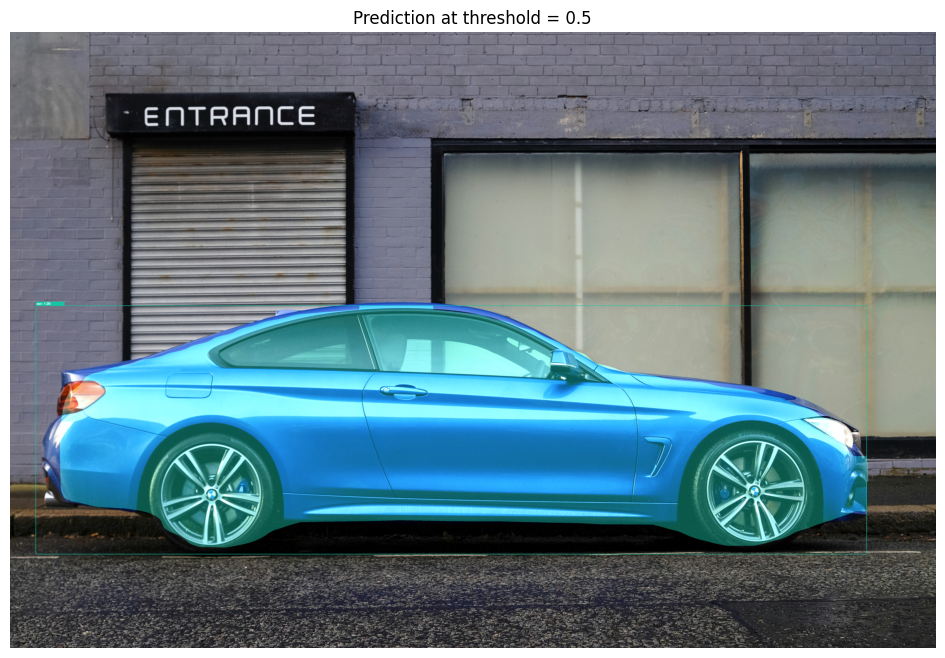

In [43]:
result = run_inference(images[0])
boxes, classes, scores, masks = extract_predictions(result, threshold=0.5)

print("Boxes shape:", boxes.shape)
print("Classes:", classes)
print("Scores:", scores)

vis = visualize_predictions(images[0], boxes, classes, scores, masks)

plt.figure(figsize=(12,8))
plt.imshow(vis)
plt.title("Prediction at threshold = 0.5")
plt.axis("off")
plt.show()


Image 1
Detected objects:
 - car (1.00)


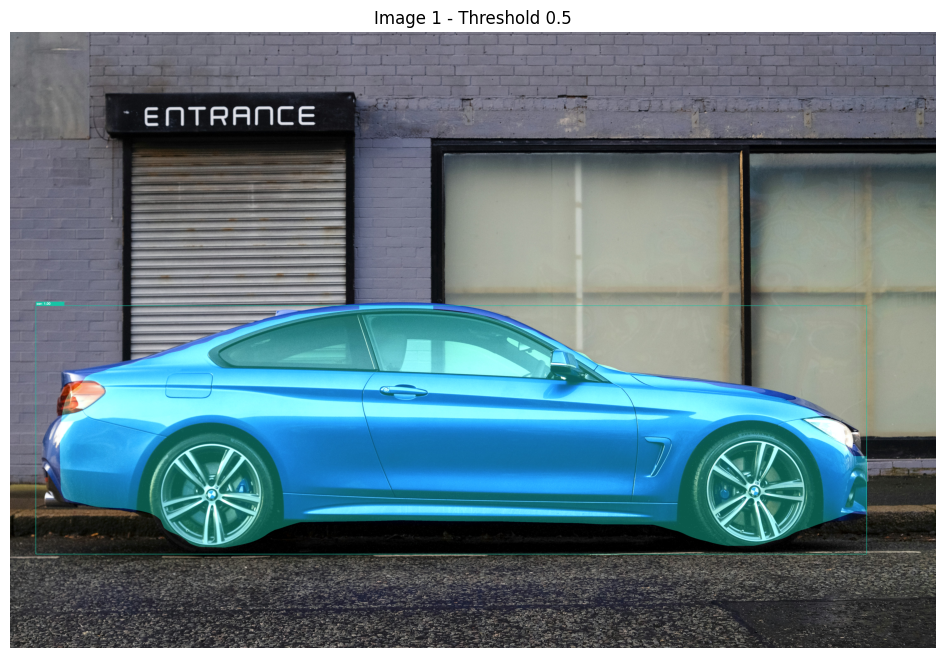


Image 2
Detected objects:
 - person (1.00)


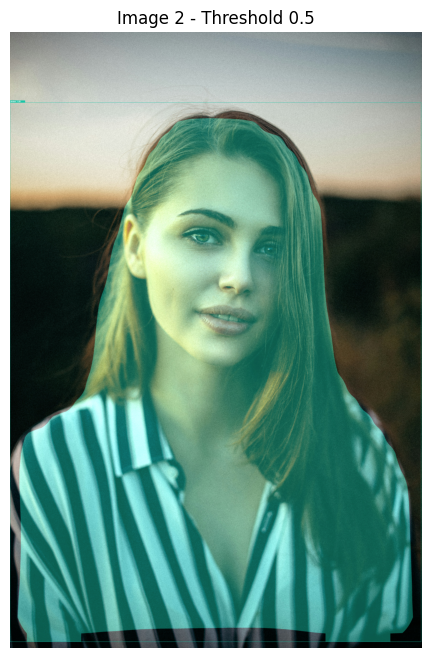


Image 3
Detected objects:
 - dog (1.00)


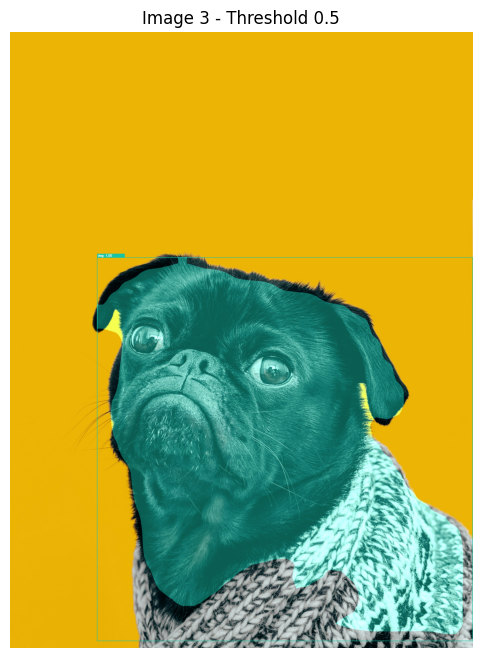


Image 4
Detected objects:
 - cup (1.00)
 - keyboard (1.00)
 - tv (1.00)
 - mouse (0.92)
 - mouse (0.81)
 - cell phone (0.80)
 - laptop (0.73)
 - cell phone (0.61)


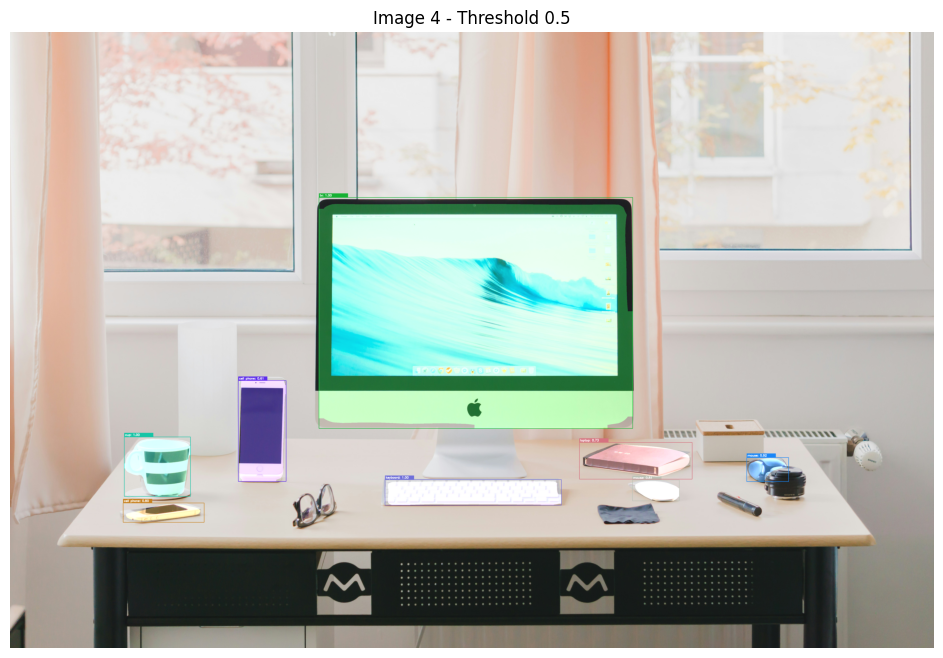


Image 5
Detected objects:
 - potted plant (0.99)
 - chair (0.96)
 - cup (0.95)
 - cup (0.94)
 - vase (0.91)
 - dining table (0.87)
 - potted plant (0.82)
 - vase (0.69)
 - bowl (0.65)


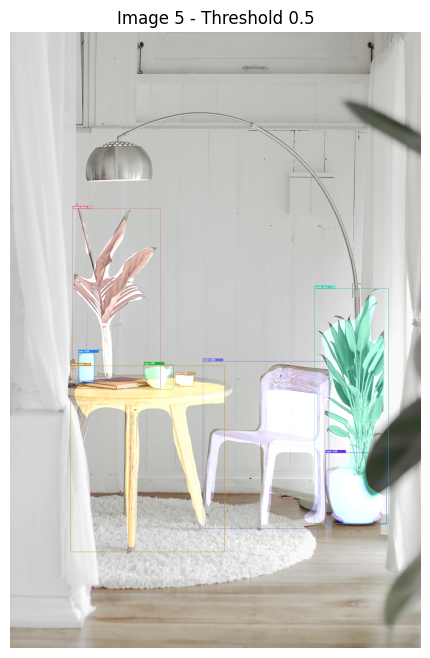

In [44]:
for idx, image in enumerate(images):
    result = run_inference(image)
    boxes, classes, scores, masks = extract_predictions(result, threshold=0.5)

    vis = visualize_predictions(image, boxes, classes, scores, masks)

    print(f"\nImage {idx+1}")
    print("Detected objects:")
    for c, s in zip(classes, scores):
        print(f" - {COCO_LABELS.get(c, c)} ({s:.2f})")

    plt.figure(figsize=(12,8))
    plt.imshow(vis)
    plt.title(f"Image {idx+1} - Threshold 0.5")
    plt.axis("off")
    plt.show()


Image 1 at threshold 0.3
Detected objects:
 - car (1.00)


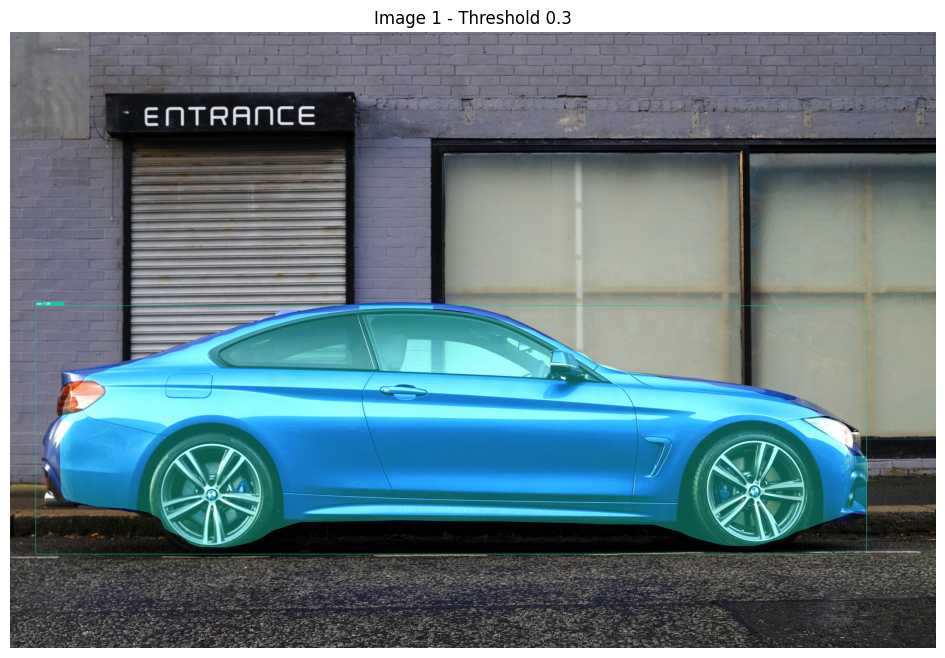


Image 2 at threshold 0.3
Detected objects:
 - person (1.00)


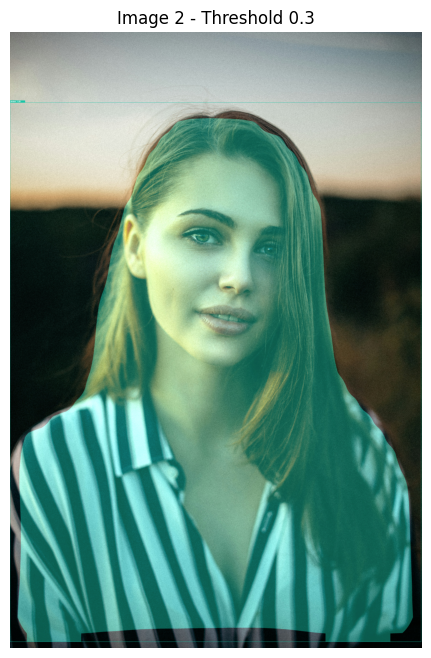


Image 3 at threshold 0.3
Detected objects:
 - dog (1.00)


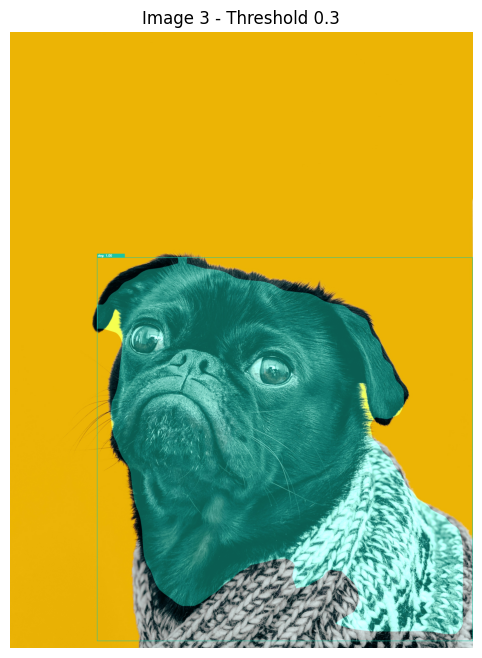


Image 4 at threshold 0.3
Detected objects:
 - cup (1.00)
 - keyboard (1.00)
 - tv (1.00)
 - mouse (0.92)
 - mouse (0.81)
 - cell phone (0.80)
 - laptop (0.73)
 - cell phone (0.61)
 - book (0.34)


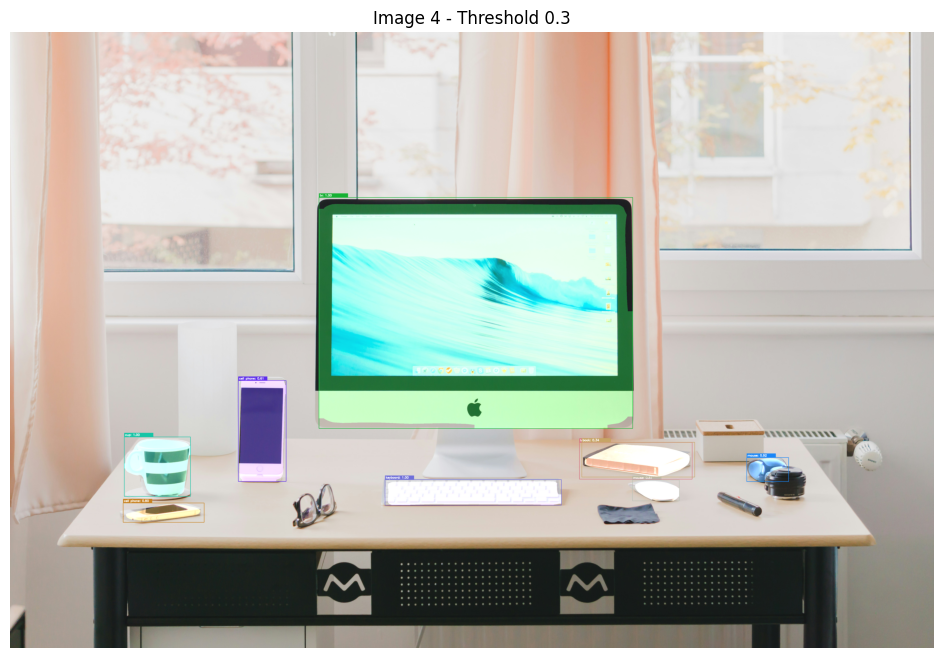


Image 5 at threshold 0.3
Detected objects:
 - potted plant (0.99)
 - chair (0.96)
 - cup (0.95)
 - cup (0.94)
 - vase (0.91)
 - dining table (0.87)
 - potted plant (0.82)
 - vase (0.69)
 - bowl (0.65)
 - person (0.31)


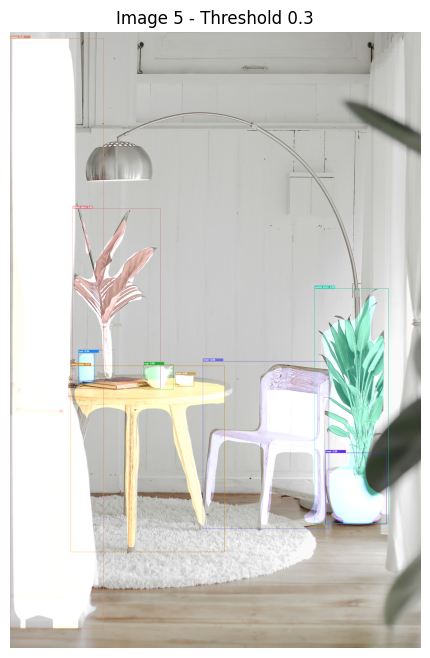

In [45]:
for idx, image in enumerate(images):
    result = run_inference(image)
    boxes, classes, scores, masks = extract_predictions(result, threshold=0.3)

    vis = visualize_predictions(image, boxes, classes, scores, masks)

    print(f"\nImage {idx+1} at threshold 0.3")
    print("Detected objects:")
    for c, s in zip(classes, scores):
        print(f" - {COCO_LABELS.get(c, c)} ({s:.2f})")

    plt.figure(figsize=(12,8))
    plt.imshow(vis)
    plt.title(f"Image {idx+1} - Threshold 0.3")
    plt.axis("off")
    plt.show()

In [46]:
for idx, image in enumerate(images):
    result = run_inference(image)
    boxes, classes, scores, masks = extract_predictions(result, threshold=0.5)

    print(f"\n{'='*60}")
    print(f"Image {idx+1}")
    print(f"{'='*60}")

    for i in range(len(boxes)):
        label = COCO_LABELS.get(classes[i], classes[i])
        print(f"Object {i+1}:")
        print("  Class label :", label)
        print("  Score       :", round(float(scores[i]), 4))
        print("  Box         :", boxes[i])
        if masks is not None:
            print("  Mask shape  :", masks[i].shape)
        print("-"*40)


Image 1
Object 1:
  Class label : car
  Score       : 0.9995
  Box         : [0.44439185 0.02797961 0.8476764  0.92516917]
  Mask shape  : (33, 33)
----------------------------------------

Image 2
Object 1:
  Class label : person
  Score       : 0.9999
  Box         : [0.11454135 0.         0.98980457 0.998137  ]
  Mask shape  : (33, 33)
----------------------------------------

Image 3
Object 1:
  Class label : dog
  Score       : 0.9982
  Box         : [0.3661735  0.18847835 0.9883964  0.9994329 ]
  Mask shape  : (33, 33)
----------------------------------------

Image 4
Object 1:
  Class label : cup
  Score       : 0.9995
  Box         : [0.6574937  0.12374555 0.7537421  0.19527908]
  Mask shape  : (33, 33)
----------------------------------------
Object 2:
  Class label : keyboard
  Score       : 0.9981
  Box         : [0.7265951  0.40591198 0.7683174  0.59680074]
  Mask shape  : (33, 33)
----------------------------------------
Object 3:
  Class label : tv
  Score       : 0.9976